# Initialize Store & Generate Tile List

Run this notebook **once** before any tile processing.

1. Loads config from `config/config_v1.txt` (use `config_with_secrets_v1.txt` for local runs with real credentials)
2. Builds a GeoDataFrame of all 10°×10° tiles with a `land` boolean column, saves `tile_list.geojson` — committed to the repo and not recomputed in CI
3. Creates the empty Icechunk/Zarr v3 store on Azure Blob Storage

After this, trigger the **Process All Tiles** GitHub Actions workflow to fill the store.

In [1]:
import sys
from pathlib import Path

import dask.array as da
import geodatasets
import geopandas as gpd
import icechunk
import numpy as np
import rioxarray
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sys.path.insert(0, str(Path.cwd().parent))
from icechunk_github_actions_demo import Config

# Use config_with_secrets_v1.txt for local runs; config_v1.txt reads credentials from env vars.
config = Config("config/config_with_secrets_v1.txt")

print("YEARS:", config.YEARS)
print("RESOLUTION:", config.RESOLUTION)
print("TILE_SIZE_DEG:", config.TILE_SIZE_DEG)
print("PIXELS_PER_TILE:", config.PIXELS_PER_TILE)
print("Global geobox:", config.global_geobox)

YEARS: [2020, 2021, 2022]
RESOLUTION: 0.01
TILE_SIZE_DEG: 10.0
PIXELS_PER_TILE: 1000
Global geobox: GeoBox((18000, 36000), Affine(0.01, 0.0, -180.0,
       0.0, -0.01, 90.0), CRS('EPSG:4326'))


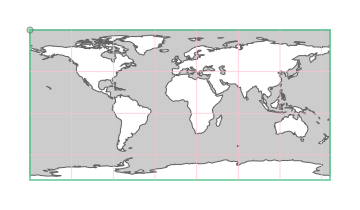

In [2]:
config.global_geobox

## 1. Build tile list and save as GeoJSON

Creates a GeoDataFrame of **all** 10°×10° tiles with a `land` boolean column,
intersected against Natural Earth land polygons loaded via `geodatasets`.
Saves `tile_list.geojson` — commit this file to the repo. CI and notebook 02
read it directly (filtering to `land=True`) without recomputing.

In [3]:
# config.global_geobox_tiles_gdf derives tile geometries from the global geobox
tiles_gdf = config.global_geobox_tiles_gdf

# Natural Earth land polygons via geodatasets
land_gdf = gpd.read_file(geodatasets.get_url("naturalearth land"))

# Mark tiles that intersect land
tiles_gdf["land"] = tiles_gdf.intersects(land_gdf.union_all())

tiles_gdf.to_file(config.TILE_LIST_PATH, driver="GeoJSON")
print(f"{tiles_gdf['land'].sum()} land tiles out of {len(tiles_gdf)} total. Geojson written to {config.TILE_LIST_PATH}")
tiles_gdf.head()

381 land tiles out of 648 total. Geojson written to /home/eric/repos/icechunk_github_actions_zarr_synergy/icechunk_github_actions_demo/tile_list.geojson


,row,col,geometry,land
0,0,0,"POLYGON ((-180 90, -180 80, -170 80, -170 90, ...",False
1,0,1,"POLYGON ((-170 90, -170 80, -160 80, -160 90, ...",False
2,0,2,"POLYGON ((-160 90, -160 80, -150 80, -150 90, ...",False
3,0,3,"POLYGON ((-150 90, -150 80, -140 80, -140 90, ...",False
4,0,4,"POLYGON ((-140 90, -140 80, -130 80, -130 90, ...",False


/tmp/ipykernel_773481/1463076886.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_773481/1463076886.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_773481/1463076886.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
/tmp/ipykernel_773481/1463076886.p

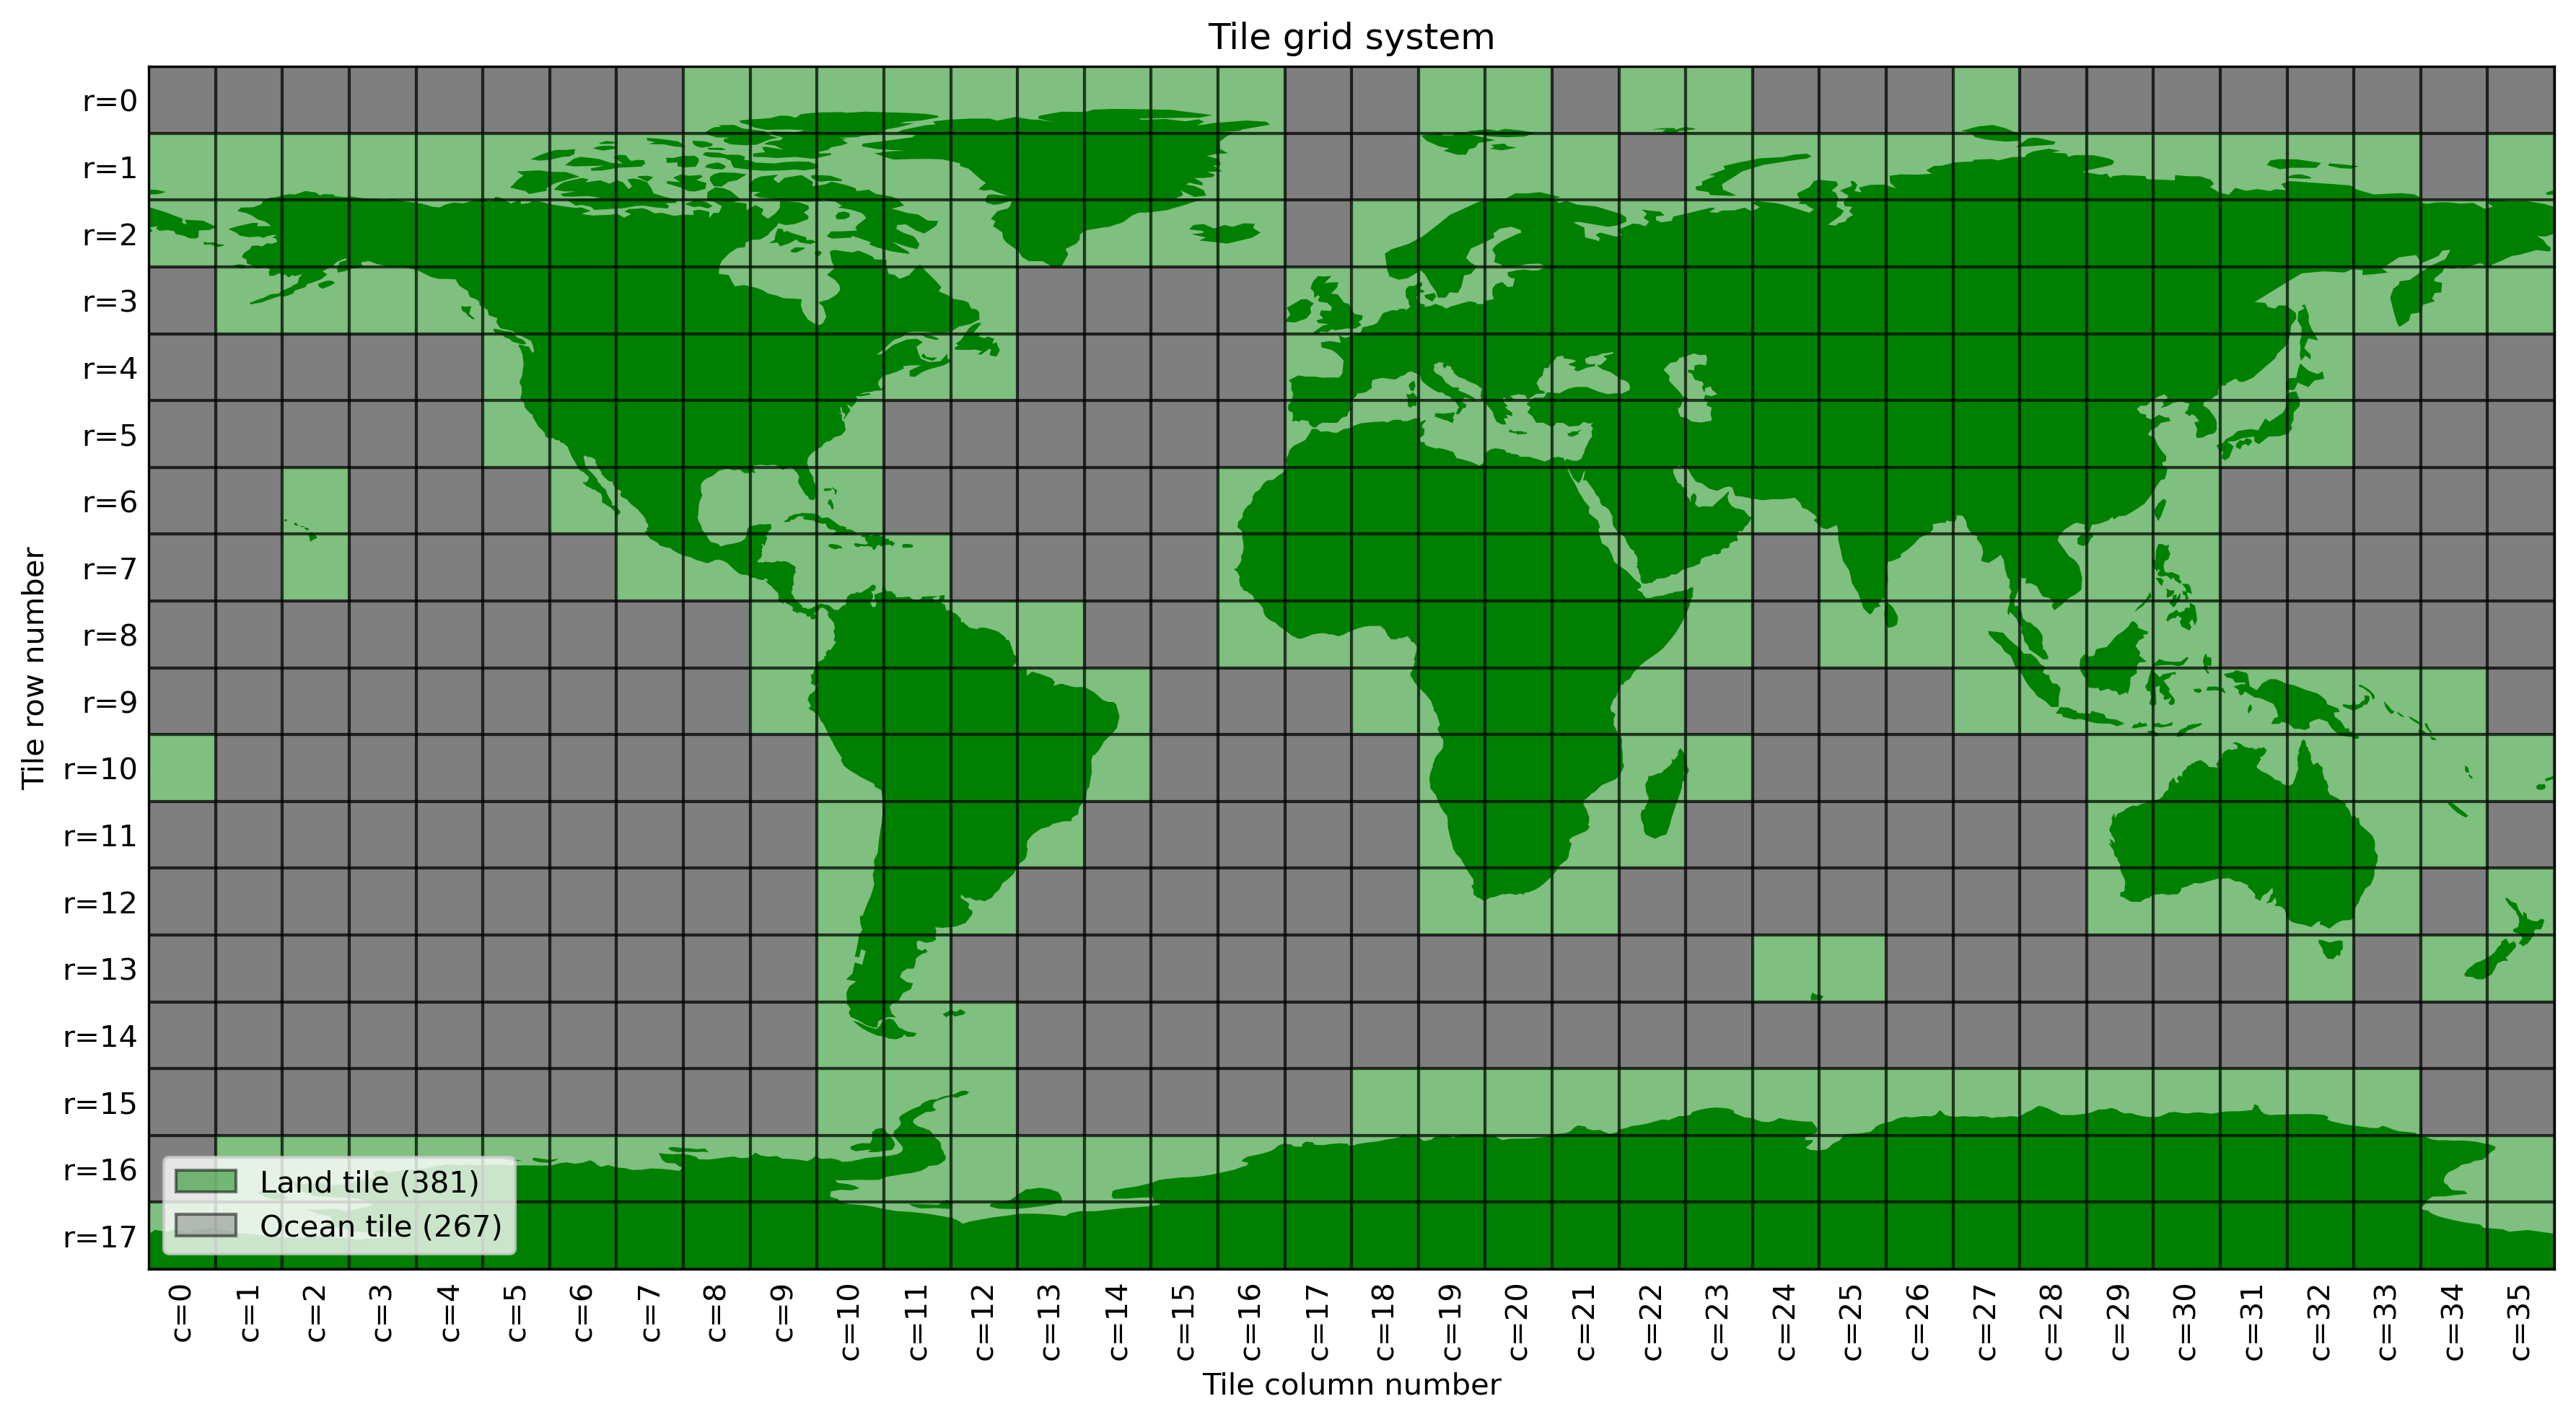

In [4]:
f, ax = plt.subplots(figsize=(12, 7), dpi=300)

land_gdf.plot(ax=ax, color="green", zorder=0)
tiles_gdf.plot(
    ax=ax,
    facecolor=tiles_gdf["land"].map({True: "green", False: "none"}),
    edgecolor="black", alpha=0.5, zorder=1,
)

ax.set_title("Tile grid system")
ax.set_xlabel("Tile column number")
ax.set_ylabel("Tile row number")

col_values = sorted(tiles_gdf["col"].unique())
row_values = sorted(tiles_gdf["row"].unique(), reverse=True)
col_coords = [tiles_gdf[tiles_gdf["col"] == h].geometry.centroid.x.mean() for h in col_values]
row_coords = [tiles_gdf[tiles_gdf["row"] == v].geometry.centroid.y.mean() for v in row_values]

ax.set_xticks(col_coords)
ax.set_xticklabels([f"c={h}" for h in col_values], rotation=90)
ax.set_yticks(row_coords)
ax.set_yticklabels([f"r={v}" for v in row_values])
ax.tick_params(axis="both", which="both", length=0)
ax.set_xlim(tiles_gdf.total_bounds[0], tiles_gdf.total_bounds[2])
ax.set_ylim(tiles_gdf.total_bounds[1], tiles_gdf.total_bounds[3])

legend_elements = [
    Patch(facecolor="green", alpha=0.5, edgecolor="black",
          label=f'Land tile ({tiles_gdf["land"].sum()})'),
    Patch(facecolor="grey", alpha=0.5, edgecolor="black",
          label=f'Ocean tile ({(~tiles_gdf["land"]).sum()})'),
]
ax.legend(handles=legend_elements, loc="lower left")
f.tight_layout()

## 2. Initialize the Icechunk store

Credentials are read from `config/config_v1.txt` (values set to `ENV` are resolved
from environment variables). For local runs, switch to `config_with_secrets_v1.txt`
in the first cell above.

This creates only metadata and coordinates — no data chunks until tile runners fill them.

In [5]:
shape  = (len(config.YEARS), config.global_geobox.shape.y, config.global_geobox.shape.x)
chunks = (1, config.PIXELS_PER_TILE, config.PIXELS_PER_TILE)

lats = np.arange(90, -90, -config.RESOLUTION) - config.RESOLUTION / 2
lons = np.arange(-180, 180, config.RESOLUTION) + config.RESOLUTION / 2

var_attrs = {
    "scale_factor": np.float32(0.02),
    "add_offset": np.float32(0.0),
    "_FillValue": config.FILL_VALUE,
    "valid_range": [7500, 65535],
    "units": "K",
    "grid_mapping": "spatial_ref",
}

ds = xr.Dataset(
    {
        "avg_daytime_lst": xr.DataArray(
            da.full(shape, np.uint16(config.FILL_VALUE), dtype=np.uint16, chunks=chunks),
            dims=["year", "latitude", "longitude"],
            attrs={**var_attrs, "long_name": "Annual mean daytime land surface temperature"},
        ),
        "max_daytime_lst": xr.DataArray(
            da.full(shape, np.uint16(config.FILL_VALUE), dtype=np.uint16, chunks=chunks),
            dims=["year", "latitude", "longitude"],
            attrs={**var_attrs, "long_name": "Annual maximum daytime land surface temperature"},
        ),
    },
    coords={"year": np.array(config.YEARS), "latitude": lats, "longitude": lons},
)
ds.attrs = {
    "title": "MODIS MOD11A2 Annual Daytime Land Surface Temperature",
    "source": "MODIS Terra MOD11A2 Version 6.1 via Microsoft Planetary Computer",
    #"Conventions": "CF-1.8",
}

# Write CRS as a spatial_ref coordinate variable so grid_mapping is satisfied on read.
# process_tile.py drops its own odc.stac-injected spatial_ref before region writes,
# leaving this one untouched in the store.
# Add CRS (GeoZarr convention: spatial_ref variable + grid_mapping attribute)
ds = ds.rio.write_crs("EPSG:4326")
# for var in ds.data_vars:
#     ds[var].attrs['grid_mapping'] = 'spatial_ref'

print(ds)
print("CRS:", ds.rio.crs)

<xarray.Dataset> Size: 8GB
Dimensions:          (year: 3, latitude: 18000, longitude: 36000)
Coordinates:
  * year             (year) int64 24B 2020 2021 2022
  * latitude         (latitude) float64 144kB 90.0 89.98 89.97 ... -89.99 -90.0
  * longitude        (longitude) float64 288kB -180.0 -180.0 ... 180.0 180.0
    spatial_ref      int64 8B 0
Data variables:
    avg_daytime_lst  (year, latitude, longitude) uint16 4GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    max_daytime_lst  (year, latitude, longitude) uint16 4GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
Attributes:
    title:    MODIS MOD11A2 Annual Daytime Land Surface Temperature
    source:   MODIS Terra MOD11A2 Version 6.1 via Microsoft Planetary Computer
CRS: EPSG:4326


In [6]:
remove_existing_store = True  # set to True to delete existing store and start fresh (warning: this will delete all existing data in the store!)

if remove_existing_store == True:
    import adlfs

    fs = adlfs.AzureBlobFileSystem(
        account_name=config.AZURE_STORAGE_ACCOUNT,
        sas_token=config.AZURE_STORAGE_SAS_TOKEN,
    )
    prefix_path = f"{config.AZURE_CONTAINER}/{config.ICECHUNK_PREFIX}"
    if fs.exists(prefix_path):
        fs.rm(prefix_path, recursive=True)
        print(f"Deleted existing store at {prefix_path}")
    else:
        print(f"No existing store found at {prefix_path}, nothing to delete")

No existing store found at snowmelt/icechunk_github_actions_demo/modis_LST_v1, nothing to delete


In [7]:
storage = icechunk.azure_storage(
    account=config.AZURE_STORAGE_ACCOUNT,
    container=config.AZURE_CONTAINER,
    prefix=config.ICECHUNK_PREFIX,
    sas_token=config.AZURE_STORAGE_SAS_TOKEN,
)

repo = icechunk.Repository.create(storage)
session = repo.writable_session("main")

ds.to_zarr(
    session.store,
    mode="w",
    zarr_format=3,
    compute=False,
    write_empty_chunks=False,
    consolidated=False,
)

snapshot_id = session.commit("initialize store: empty template")
print(f"Store initialized at {prefix_path}. Snapshot ID: {snapshot_id}")

Store initialized at snowmelt/icechunk_github_actions_demo/modis_LST_v1. Snapshot ID: TFXSPCX1TTEE8T9FTT30


In [8]:
session_ro = repo.readonly_session('main')
ds_verify = xr.open_zarr(session_ro.store, zarr_format=3, consolidated=False, decode_coords='all')
print(ds_verify)
print('CRS:', ds_verify.rio.crs)

<xarray.Dataset> Size: 31GB
Dimensions:          (year: 3, latitude: 18000, longitude: 36000)
Coordinates:
  * year             (year) int64 24B 2020 2021 2022
  * latitude         (latitude) float64 144kB 90.0 89.98 89.97 ... -89.99 -90.0
  * longitude        (longitude) float64 288kB -180.0 -180.0 ... 180.0 180.0
    spatial_ref      int64 8B ...
Data variables:
    avg_daytime_lst  (year, latitude, longitude) float64 16GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    max_daytime_lst  (year, latitude, longitude) float64 16GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
Attributes:
    title:    MODIS MOD11A2 Annual Daytime Land Surface Temperature
    source:   MODIS Terra MOD11A2 Version 6.1 via Microsoft Planetary Computer
CRS: EPSG:4326
